In [37]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

In [38]:
# Przykładowe dane
X = torch.randn(100, 3)
y = X @ torch.tensor([2.0, -3.0, 1.0]) + 0.5 * torch.randn(100)

# Model liniowy
model = nn.Linear(3, 1, bias=True)

# Parametry
lr = 0.01
lambda_l1 = 0.1  # siła regularyzacji L1

optimizer = optim.SGD(model.parameters(), lr=lr)

for epoch in range(1000):
    optimizer.zero_grad()
    y_pred = model(X).squeeze()
    
    mse_loss = torch.mean((y - y_pred) ** 2)
    l1_penalty = sum(torch.sum(torch.abs(param)) for param in model.parameters())
    loss = mse_loss + lambda_l1 * l1_penalty

    loss.backward()
    optimizer.step()

# Wyniki
print("Współczynniki:", model.weight.data)
print("Bias:", model.bias.data)

Współczynniki: tensor([[ 1.9308, -2.8649,  0.9451]])
Bias: tensor([-0.0006])


mse_loss — klasyczna funkcja błędu dla regresji.

l1_penalty — suma wartości bezwzględnych wag (L1).

lambda_l1 — współczynnik regularyzacji, który kontroluje siłę „karania” dużych wag (większa wartość = więcej zer).

In [39]:
[torch.abs(param) for param in model.parameters()]

[tensor([[1.9308, 2.8649, 0.9451]], grad_fn=<AbsBackward0>),
 tensor([0.0006], grad_fn=<AbsBackward0>)]

autograd w PyTorch to system automatycznego różniczkowania – czyli mechanizm, który sam liczy pochodne (gradienty) funkcji zbudowanych na tensorach.

Normalnie obliczanie pochodnych dla skomplikowanych sieci byłoby koszmarem matematycznym.
Dlatego autograd robi to automatycznie — wystarczy, że zbudujesz obliczenia w PyTorch i wywołasz backward().

In [40]:
# Tworzymy tensor z możliwością śledzenia gradientu
x = torch.tensor(2.0, requires_grad=True)

# Definiujemy prostą funkcję
y = 3 * x**2 + 2 * x + 1

# Obliczamy pochodną dy/dx
y.backward()

# Wyświetlamy gradient
print(x.grad)  # 8.0, bo dy/dx = 6x + 2 → 6*2 + 2 = 14

tensor(14.)


In [41]:
x = torch.tensor(2.0, requires_grad=True)
y = 3 * x
z = x**2
v = 2 * x
y.backward()
z.backward()
v.backward()


In [42]:
x, x.grad

(tensor(2., requires_grad=True), tensor(9.))

| Pojęcie              | Znaczenie                                                |
| -------------------- | -------------------------------------------------------- |
| `requires_grad=True` | PyTorch śledzi operacje na tym tensorze                  |
| `.backward()`        | oblicza pochodne (gradienty)                             |
| `.grad`              | przechowuje obliczony gradient                           |
| `torch.no_grad()`    | wyłącza śledzenie gradientów (np. przy ewaluacji modelu) |


Przykład: autograd w regresji liniowej

Zróbmy najprostszą możliwą regresję:
mamy dane x, y, a model to 
𝑦^=𝑤𝑥+𝑏y^

Chcemy minimalizować błąd kwadratowy 
𝐿=(𝑦−𝑦^)**2

In [43]:
# Dane
x = torch.tensor([1.0, 2.0, 3.0])
y = torch.tensor([2.0, 4.0, 6.0])

# Parametry modelu (z gradientem)
w = torch.tensor(0.0, requires_grad=True)
b = torch.tensor(0.0, requires_grad=True)

# Obliczenia
y_pred = w * x + b
loss = torch.mean((y - y_pred) ** 2)  # funkcja kosztu MSE

# Obliczamy gradienty
loss.backward()

print(f"Gradient w: {w.grad}")
print(f"Gradient b: {b.grad}")

Gradient w: -18.666667938232422
Gradient b: -8.0


In [44]:
w * x + b

tensor([0., 0., 0.], grad_fn=<AddBackward0>)

In [45]:
import torch.nn as nn

def wasserstein_loss(y_pred, y_true):
    """
    Oblicza 1D Wasserstein distance między dwoma rozkładami:
    predykcjami i wartościami rzeczywistymi.
    """
    # Sortujemy oba zbiory (ważne dla 1D Wasserstein)
    y_pred_sorted, _ = torch.sort(y_pred.view(-1))
    y_true_sorted, _ = torch.sort(y_true.view(-1))
    
    # Upewniamy się, że mają taki sam rozmiar
    n = min(y_pred_sorted.size(0), y_true_sorted.size(0))
    y_pred_sorted = y_pred_sorted[:n]
    y_true_sorted = y_true_sorted[:n]
    
    # Średnia różnica absolutna
    loss = torch.mean(torch.abs(y_pred_sorted - y_true_sorted))
    return loss


In [46]:
# Dane przykładowe
x = torch.linspace(-2, 2, 100).unsqueeze(1)
y_true = 3 * x + torch.randn_like(x) * 0.5  # "rzeczywiste" dane

# Model liniowy
model = nn.Linear(1, 1)

optimizer = torch.optim.Adam(model.parameters(), lr=0.05)

for epoch in range(5000):
    optimizer.zero_grad()
    y_pred = model(x)
    loss = wasserstein_loss(y_pred, y_true)
    loss.backward()
    optimizer.step()

print("Parametry modelu:", list(model.parameters()))
print("Ostateczny Wasserstein loss:", loss.item())


Parametry modelu: [Parameter containing:
tensor([[2.9600]], requires_grad=True), Parameter containing:
tensor([-0.0288], requires_grad=True)]
Ostateczny Wasserstein loss: 0.17531265318393707


In [47]:
# Dane przykładowe
x = torch.linspace(-2, 2, 100).unsqueeze(1)
y_true = 3 * x + torch.randn_like(x) * 0.5  # "rzeczywiste" dane

# Model liniowy
model = nn.Linear(1, 1)

optimizer = torch.optim.Adam(model.parameters(), lr=0.05)

for epoch in range(5000):
    optimizer.zero_grad()
    y_pred = model(x)
    loss = torch.mean((y - y_pred) ** 2)
    loss.backward()
    optimizer.step()

print("Parametry modelu:", list(model.parameters()))
print("Ostateczny  loss:", loss.item())

Parametry modelu: [Parameter containing:
tensor([[3.1390e-08]], requires_grad=True), Parameter containing:
tensor([4.], requires_grad=True)]
Ostateczny  loss: 2.6666667461395264


In [48]:
x = torch.linspace(-2, 2, 100).unsqueeze(1)

In [49]:
torch.randn_like(x)

tensor([[-0.3378],
        [-0.1206],
        [-0.0261],
        [ 0.8415],
        [ 0.2156],
        [ 0.9847],
        [-0.3054],
        [-1.7254],
        [-1.8951],
        [-0.0965],
        [-2.0423],
        [ 1.7543],
        [-0.5650],
        [ 0.1033],
        [ 1.4926],
        [ 0.3750],
        [-0.3692],
        [ 0.4423],
        [ 0.4473],
        [-0.1772],
        [ 0.2711],
        [ 0.3326],
        [-1.0401],
        [ 1.3382],
        [ 0.0724],
        [ 0.5458],
        [ 1.4157],
        [ 0.0673],
        [-0.1549],
        [ 0.0028],
        [-0.5305],
        [ 1.0101],
        [-0.3710],
        [ 1.3304],
        [-0.6437],
        [-0.6647],
        [ 0.0304],
        [ 1.4090],
        [-0.9191],
        [-1.1641],
        [-1.4789],
        [-1.2574],
        [-0.8213],
        [ 0.1936],
        [ 1.0133],
        [-0.4888],
        [-0.4865],
        [-0.6895],
        [ 0.5505],
        [-0.0256],
        [-0.3073],
        [ 0.7641],
        [ 0.

In [50]:
# Dane przykładowe
x = torch.linspace(0, 100, 100).unsqueeze(1)
y_true = 3 * x + torch.randn_like(x) * 0.5  # "rzeczywiste" dane

n0 = torch.tensor(0.0, requires_grad=True)
w = torch.tensor(0.0, requires_grad=True)
# Model liniowy
# model = nn.Linear(1, 1) * torch.exp(nn.Linear(1, 1))

# optimizer = torch.optim.Adam(model.parameters(), lr=0.05)
optimizer = torch.optim.Adam([n0, w], lr=0.05)

for epoch in range(5000):
    optimizer.zero_grad()
    # y_pred = model(x)
    y_pred = n0 * torch.exp(w * x)
    loss = torch.mean((y - y_pred) ** 2)
    loss.backward()
    optimizer.step()

print("Parametry modelu:", list(model.parameters()))
print("Ostateczny  loss:", loss.item())

Parametry modelu: [Parameter containing:
tensor([[3.1390e-08]], requires_grad=True), Parameter containing:
tensor([4.], requires_grad=True)]
Ostateczny  loss: 18.475942611694336


In [51]:
from pathlib import Path
from config import DATA_DIR
import pandas as pd

data = pd.read_csv(DATA_DIR / 'pkn_d.csv')

In [52]:
data

,Data,Otwarcie,Najwyzszy,Najnizszy,Zamkniecie,Wolumen
0,1999-11-26,11.6218,11.7245,11.2009,11.5655,2.083188e+07
1,1999-11-29,11.5122,11.5655,11.3052,11.3592,7.224482e+06
2,1999-11-30,11.4634,11.6691,11.4634,11.5655,4.318359e+06
3,1999-12-01,11.6691,11.9308,11.5655,11.9308,4.043341e+06
4,1999-12-02,12.0404,12.4050,11.9849,12.1440,4.340596e+06
...,...,...,...,...,...,...
6475,2025-10-09,88.1000,89.5000,87.9100,88.8800,1.860879e+06
6476,2025-10-10,88.8800,89.4000,87.7600,89.0000,2.012617e+06
6477,2025-10-13,87.5000,88.9500,87.2700,88.6300,1.300188e+06
6478,2025-10-14,87.6000,87.7800,84.8500,87.1300,1.776149e+06


In [53]:
# data[:100].Zamkniecie.to_numpy() - y_true
start = 1500
stop = 3000
y_true = torch.tensor(data[start:stop].Zamkniecie.to_numpy()).reshape(-1, 1)
x = torch.linspace(start, stop, stop-start).unsqueeze(1)

n0 = torch.tensor(0.0, requires_grad=True) # 2.001
w = torch.tensor(0.0, requires_grad=True) # 0.0012
b = torch.tensor(0.0, requires_grad=True) # 8.2874

optimizer = torch.optim.Adam([n0, w, b], lr=0.00005)

In [54]:
epoch_arr = []
loss_arr = []
for epoch in range(500):
    optimizer.zero_grad()
    y_pred = n0 * torch.exp(w * x) + b
    loss = torch.sum((y_true - y_pred) ** 2)
    loss.backward()
    optimizer.step()
    if epoch % 1000 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")
        epoch_arr.append(epoch)
        loss_arr.append(loss.item())


Epoch 0, Loss: 905000.1692


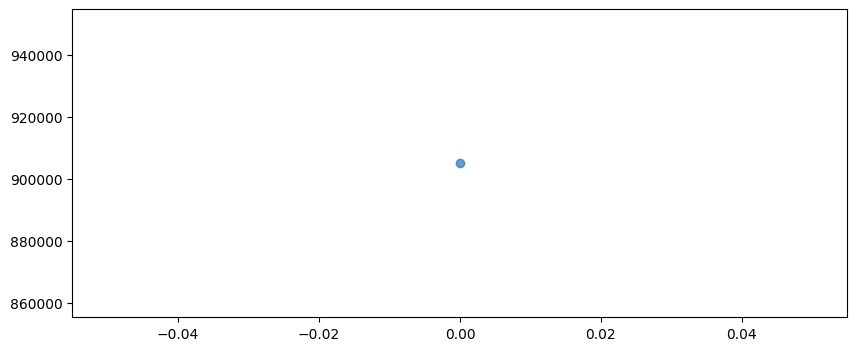

In [55]:
import matplotlib.pyplot as plt

# Tworzymy wykres
plt.figure(figsize=(10, 4))
plt.scatter(epoch_arr, loss_arr, alpha=0.7, label="true values")


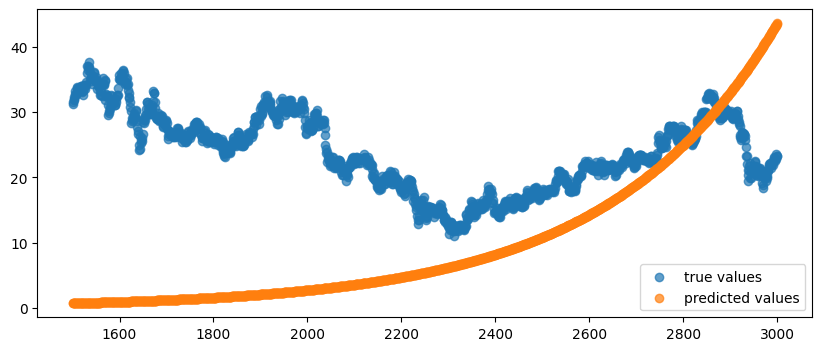

In [56]:


# Załóżmy, że masz dane:
# y  -> wartości prawdziwe
# y_pred -> przewidywania modelu

# Jeśli to tensory PyTorcha, trzeba je przekonwertować na NumPy
y_true_np = y_true.detach().cpu().numpy().flatten()
y_pred_np = y_pred.detach().cpu().numpy().flatten()

# Tworzymy wykres
plt.figure(figsize=(10, 4))

plt.scatter(x, y_true_np, alpha=0.7, label="true values")
plt.scatter(x, y_pred_np, alpha=0.7, label="predicted values")
plt.legend()


In [57]:
w, n0, b, y_pred_np

(tensor(0.0028, requires_grad=True),
 tensor(0.0099, requires_grad=True),
 tensor(0.0216, requires_grad=True),
 array([ 0.67960906,  0.681453  ,  0.68330234, ..., 43.417267  ,
        43.538864  , 43.660797  ], shape=(1500,), dtype=float32))

In [ ]:
steps = 40
n = len(y_true) // steps

start = 0
stop = 0
n_arr = []
w_arr = []
b_arr = []

for step in range(steps-1):

    start = stop
    stop = start + n
    print(start, stop)
    
    y_true = torch.tensor(data[start:stop].Zamkniecie.to_numpy()).reshape(-1, 1)
    x = torch.linspace(0, n, n).unsqueeze(1)

    
    if step == 0:
        b = torch.tensor(0.0, requires_grad=True)
        n0 = torch.tensor(0.0, requires_grad=True) 
        w = torch.tensor(0.0, requires_grad=True) 
        optimizer = torch.optim.Adam([n0, w, b], lr=0.00005)
    else:
        n0 = n1
        b = torch.tensor(0.0, requires_grad=True)
        w = torch.tensor(w_arr[-1], requires_grad=True) 
        optimizer = torch.optim.Adam([w], lr=0.00005)


    for epoch in range(100000):
        optimizer.zero_grad()
        y_pred = n0 * torch.exp(w * x) + b
        loss = torch.sum((y_true - y_pred) ** 2)
        loss.backward()
        optimizer.step()
        if epoch % 1000 == 0:
            print(f"Step {step}, Epoch {epoch}, Loss: {loss.item():.4f}")
    n_arr.append(n0.item())
    w_arr.append(w.item())
    b_arr.append(b.item())
    loss_arr.append(loss.item())
    n1 = y_pred.detach()[-1]

0 162
Step 0, Epoch 0, Loss: 23969.8368
Step 0, Epoch 1000, Loss: 17109.2220
Step 0, Epoch 2000, Loss: 16364.4341
Step 0, Epoch 3000, Loss: 15738.7319
Step 0, Epoch 4000, Loss: 15181.1812
Step 0, Epoch 5000, Loss: 14669.4882
Step 0, Epoch 6000, Loss: 14193.3029
Step 0, Epoch 7000, Loss: 13746.9627
Step 0, Epoch 8000, Loss: 13326.6411
Step 0, Epoch 9000, Loss: 12929.3224
Step 0, Epoch 10000, Loss: 12552.4260
Step 0, Epoch 11000, Loss: 12193.7815
Step 0, Epoch 12000, Loss: 11851.4108
Step 0, Epoch 13000, Loss: 11523.7804
Step 0, Epoch 14000, Loss: 11209.4362
Step 0, Epoch 15000, Loss: 10907.2190
Step 0, Epoch 16000, Loss: 10616.1324
Step 0, Epoch 17000, Loss: 10335.2722
Step 0, Epoch 18000, Loss: 10063.8102
Step 0, Epoch 19000, Loss: 9801.1600
Step 0, Epoch 20000, Loss: 9546.7432
Step 0, Epoch 21000, Loss: 9300.0275
Step 0, Epoch 22000, Loss: 9060.5538
Step 0, Epoch 23000, Loss: 8827.9684
Step 0, Epoch 24000, Loss: 8601.7258
Step 0, Epoch 25000, Loss: 8381.7547
Step 0, Epoch 26000, Loss:

6480


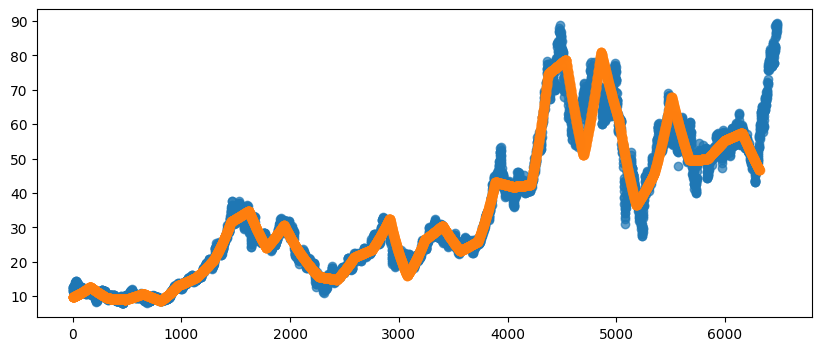

In [ ]:
n_arr, w_arr
y_arr = []
for step in range(steps-1):
    if step == 0:
        y_arr += list(n_arr[step] * np.exp(w_arr[step] * np.linspace(0, n, n)) + b_arr[step])
    else:
        y_arr += list(n_arr[step] * np.exp(w_arr[step] * np.linspace(0, n, n)))

y_true = torch.tensor(data.Zamkniecie.to_numpy()).reshape(-1, 1)
print(len(y_true))
plt.figure(figsize=(10, 4))
plt.scatter(range(len(y_true)), y_true, alpha=0.7, label="true values")
plt.scatter(range(len(y_arr)), y_arr, alpha=0.7, label="predicted values")

39


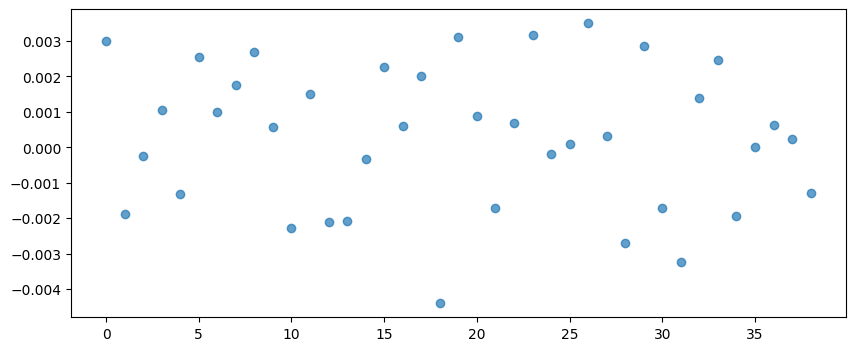

In [91]:
print(len(w_arr))
plt.figure(figsize=(10, 4))
plt.scatter(range(len(w_arr)), w_arr, alpha=0.7, label="true values")


In [ ]:
steps = 100
n = len(y_true) // steps

start = 0
stop = 0
n_arr = []
w_arr = []
b_arr = []
for step in range(steps-1):

    start = stop
    stop = start + n
    print(start, stop)
    
    y_true = torch.tensor(data[start:stop].Zamkniecie.to_numpy()).reshape(-1, 1)
    x = torch.linspace(0, n, n).unsqueeze(1)

    
    if step == 0:
        b = torch.tensor(0.0, requires_grad=True)
        n0 = torch.tensor(0.0, requires_grad=True) 
        w = torch.tensor(0.0, requires_grad=True) 
        optimizer = torch.optim.Adam([n0, w, b], lr=0.00005)
    else:
        n0 = n1
        b = torch.tensor(0.0, requires_grad=True)
        w = torch.tensor(w_arr[-1], requires_grad=True) 
        optimizer = torch.optim.Adam([w], lr=0.00005)


    for epoch in range(100000):
        optimizer.zero_grad()
        y_pred = n0 * torch.exp(w * x) + b
        loss = torch.sum((y_true - y_pred) ** 2)
        loss.backward()
        optimizer.step()
        if epoch % 1000 == 0:
            print(f"Step {step}, Epoch {epoch}, Loss: {loss.item():.4f}")
    n_arr.append(n0.item())
    w_arr.append(w.item())
    b_arr.append(b.item())
    loss_arr.append(loss.item())
    n1 = y_pred.detach()[-1]

0 64
Step 0, Epoch 0, Loss: 10866.1931
Step 0, Epoch 1000, Loss: 7327.1577
Step 0, Epoch 2000, Loss: 7062.4760
Step 0, Epoch 3000, Loss: 6800.5666
Step 0, Epoch 4000, Loss: 6556.0149
Step 0, Epoch 5000, Loss: 6329.0064
Step 0, Epoch 6000, Loss: 6117.5433
Step 0, Epoch 7000, Loss: 5919.6373
Step 0, Epoch 8000, Loss: 5733.5872
Step 0, Epoch 9000, Loss: 5557.9560
Step 0, Epoch 10000, Loss: 5391.5364
Step 0, Epoch 11000, Loss: 5233.2957
Step 0, Epoch 12000, Loss: 5082.3731
Step 0, Epoch 13000, Loss: 4938.0554
Step 0, Epoch 14000, Loss: 4799.6710
Step 0, Epoch 15000, Loss: 4666.7388
Step 0, Epoch 16000, Loss: 4538.7892
Step 0, Epoch 17000, Loss: 4415.4023
Step 0, Epoch 18000, Loss: 4296.2485
Step 0, Epoch 19000, Loss: 4181.0452
Step 0, Epoch 20000, Loss: 4069.5332
Step 0, Epoch 21000, Loss: 3961.4580
Step 0, Epoch 22000, Loss: 3856.6346
Step 0, Epoch 23000, Loss: 3754.8609
Step 0, Epoch 24000, Loss: 3655.9827
Step 0, Epoch 25000, Loss: 3559.8479
Step 0, Epoch 26000, Loss: 3466.3239
Step 0, 

6480


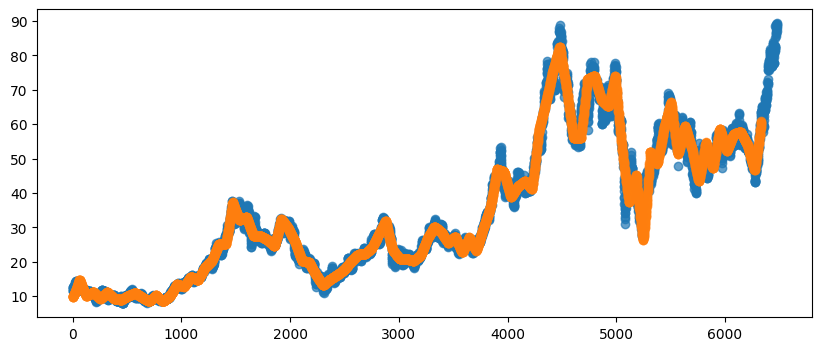

In [95]:
n_arr, w_arr
y_arr = []
for step in range(steps-1):
    if step == 0:
        y_arr += list(n_arr[step] * np.exp(w_arr[step] * np.linspace(0, n, n)) + b_arr[step])
    else:
        y_arr += list(n_arr[step] * np.exp(w_arr[step] * np.linspace(0, n, n)))

y_true = torch.tensor(data.Zamkniecie.to_numpy()).reshape(-1, 1)
print(len(y_true))
plt.figure(figsize=(10, 4))
plt.scatter(range(len(y_true)), y_true, alpha=0.7, label="true values")
plt.scatter(range(len(y_arr)), y_arr, alpha=0.7, label="predicted values")

Text(0, 0.5, 'Weight value')

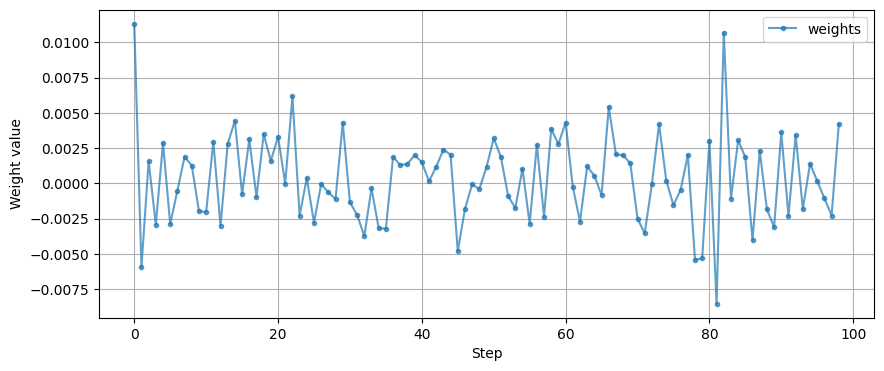

In [97]:
plt.figure(figsize=(10, 4))
plt.plot(range(len(w_arr)), w_arr, alpha=0.7, label="weights", marker='.')
plt.legend()
plt.grid(True)
plt.xlabel('Step')
plt.ylabel('Weight value')

In [98]:
steps = 250
n = len(y_true) // steps

start = 0
stop = 0
n_arr = []
w_arr = []
b_arr = []
for step in range(steps-1):

    start = stop
    stop = start + n
    print(start, stop)
    
    y_true = torch.tensor(data[start:stop].Zamkniecie.to_numpy()).reshape(-1, 1)
    x = torch.linspace(0, n, n).unsqueeze(1)

    
    if step == 0:
        b = torch.tensor(0.0, requires_grad=True)
        n0 = torch.tensor(0.0, requires_grad=True) 
        w = torch.tensor(0.0, requires_grad=True) 
        optimizer = torch.optim.Adam([n0, w, b], lr=0.00005)
    else:
        n0 = n1
        b = torch.tensor(0.0, requires_grad=True)
        w = torch.tensor(w_arr[-1], requires_grad=True) 
        optimizer = torch.optim.Adam([w], lr=0.00005)


    for epoch in range(100000):
        optimizer.zero_grad()
        y_pred = n0 * torch.exp(w * x) + b
        loss = torch.sum((y_true - y_pred) ** 2)
        loss.backward()
        optimizer.step()
        if epoch % 1000 == 0:
            print(f"Step {step}, Epoch {epoch}, Loss: {loss.item():.4f}")
    n_arr.append(n0.item())
    w_arr.append(w.item())
    b_arr.append(b.item())
    loss_arr.append(loss.item())
    n1 = y_pred.detach()[-1]

0 25
Step 0, Epoch 0, Loss: 4019.5615
Step 0, Epoch 1000, Loss: 3819.0627
Step 0, Epoch 2000, Loss: 2348.9751
Step 0, Epoch 3000, Loss: 2245.5183
Step 0, Epoch 4000, Loss: 2180.4712
Step 0, Epoch 5000, Loss: 2109.3006
Step 0, Epoch 6000, Loss: 2037.4952
Step 0, Epoch 7000, Loss: 1968.1394
Step 0, Epoch 8000, Loss: 1902.2748
Step 0, Epoch 9000, Loss: 1839.9563
Step 0, Epoch 10000, Loss: 1780.9116
Step 0, Epoch 11000, Loss: 1724.8084
Step 0, Epoch 12000, Loss: 1671.3430
Step 0, Epoch 13000, Loss: 1620.2405
Step 0, Epoch 14000, Loss: 1571.2809
Step 0, Epoch 15000, Loss: 1524.2812
Step 0, Epoch 16000, Loss: 1479.0682
Step 0, Epoch 17000, Loss: 1435.5001
Step 0, Epoch 18000, Loss: 1393.4638
Step 0, Epoch 19000, Loss: 1352.8517
Step 0, Epoch 20000, Loss: 1313.5726
Step 0, Epoch 21000, Loss: 1275.5397
Step 0, Epoch 22000, Loss: 1238.6712
Step 0, Epoch 23000, Loss: 1202.9076
Step 0, Epoch 24000, Loss: 1168.2015
Step 0, Epoch 25000, Loss: 1134.4826
Step 0, Epoch 26000, Loss: 1101.7173
Step 0, E

6480


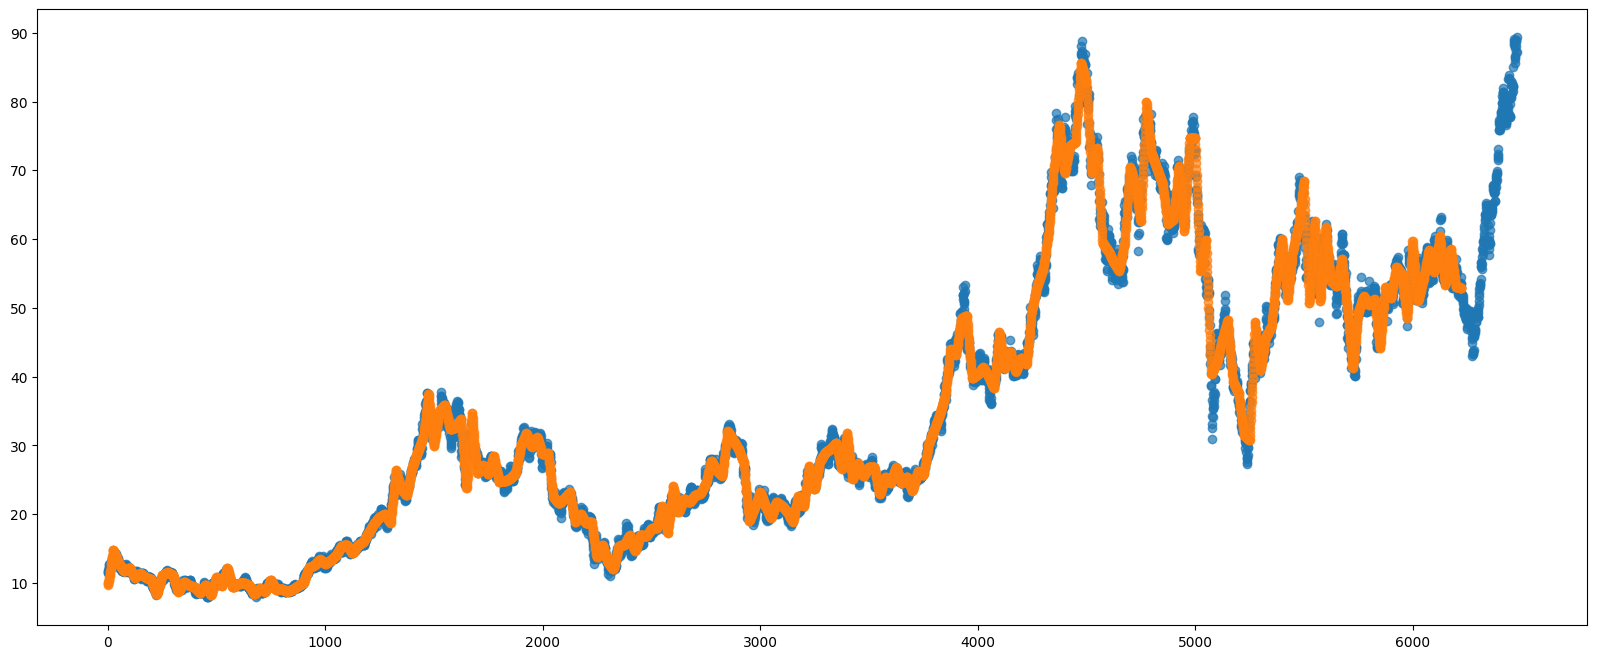

: 

In [ ]:
n_arr, w_arr
y_arr = []
for step in range(steps-1):
    if step == 0:
        y_arr += list(n_arr[step] * np.exp(w_arr[step] * np.linspace(0, n, n)) + b_arr[step])
    else:
        y_arr += list(n_arr[step] * np.exp(w_arr[step] * np.linspace(0, n, n)))

y_true = torch.tensor(data.Zamkniecie.to_numpy()).reshape(-1, 1)
print(len(y_true))
plt.figure(figsize=(20, 8))
plt.scatter(range(len(y_true)), y_true, alpha=0.7, label="true values")
plt.scatter(range(len(y_arr)), y_arr, alpha=0.7, label="predicted values")

Text(0, 0.5, 'Weight value')

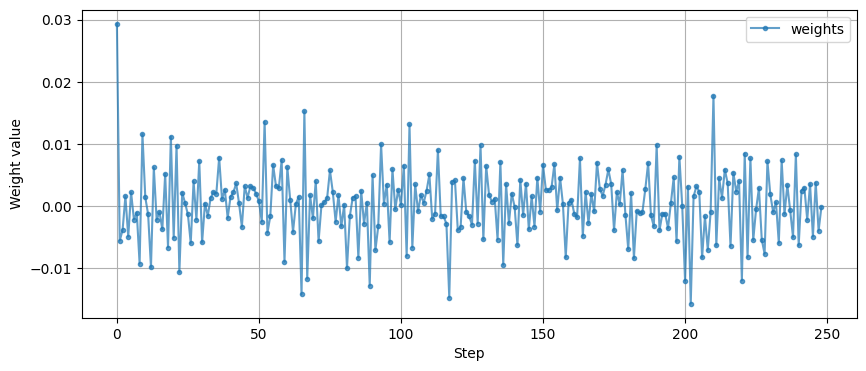

In [102]:
plt.figure(figsize=(10, 4))
plt.plot(range(len(w_arr)), w_arr, alpha=0.7, label="weights", marker='.')
plt.legend()
plt.grid(True)
plt.xlabel('Step')
plt.ylabel('Weight value')

In [105]:
np.mean(w_arr), np.average(w_arr), np.median(w_arr)

(np.float64(0.0003218943138380561),
 np.float64(0.0003218943138380561),
 np.float64(0.0005349600687623024))